# Does the Relative Vigor Index actually forecast? 📊
### A popular momentum oscillator — body vs range, with a signal line — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![RVI_cross_forecasts%3F: Busted](https://img.shields.io/badge/RVI_cross_forecasts%3F-Busted-8b949e?style=flat-square)

Open any charting package and you'll find the **Relative Vigor Index (RVI)**: a wiggly line with a faster *signal line* riding on top of it. The idea, from John Ehlers, is simple and appealing — *in an up-trend a market closes above its open*, so the RVI reads the bar **body** (close − open) against the bar **range** (high − low) and smooths it. The lore, repeated on every chart-pattern site, is that when the **RVI crosses above its signal line**, vigour is turning up — so you **buy**.

It *looks* uncanny when you scroll a chart and spot the crosses that preceded rallies. But picking the good crosses after the fact is the textbook way to fool yourself. So we did the only fair thing: encode the RVI **mechanically** (no eyeballing), fire the "buy the cross" rule thousands of times across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from relative_vigor_index import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real RVI cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 2427, 'period': 10, 'fp_spy': '4cb5244f3990', 'h5': (5, 2425, 19.5, 56, 4.07, 24.5, -5.0, 17.5, -0.66, 0.511), 'h10': (10, 2423, 49.4, 59, 6.43, 62.0, -12.6, 47.4, -1.18, 0.239), 'h20': (20, 2416, 99.6, 64, 7.39, 105.0, -5.4, 97.6, -0.37, 0.714), 'h60': (60, 2407, 295.2, 69, 8.36, 283.3, 11.9, 293.2, 0.49, 0.621), 'per': [('SPY', 485, 93.3, 3.44, 115.2, -21.8), ('QQQ', 470, 144.0, 4.7, 107.1, 37.0), ('IWM', 492, 84.0, 2.35, 106.5, -22.5), ('DIA', 472, 93.9, 4.08, 84.8, 9.1), ('GLD', 508, 84.7, 3.03, 110.5, -25.8)], 'placebo': (93.3, 0.557, 500), 'syn': [(0.0, 344, -7.2, 47, -0.18), (0.6, 317, 324.1, 60, 2.88)]}


real RVI cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when the RVI crosses above its signal, do I make money? | **Yes — but only because the market goes up.** The raw win-rate is ~60% and the returns look great. |
| Is that *the cross's* doing? | **No.** Buy on **random days** instead and you do **just as well or better**. At 5/10/20 days the cross is actually *worse* than a coin-flip entry. |
| Does the cross "forecast" the move? | **Not in any usable way.** Scramble the cross's timing and the result barely changes. The specific cross isn't doing the work. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a momentum trigger. |

> The RVI is a fine way to *describe* momentum after the fact. As a *forecast* — "the cross means a rally is coming" — it's a **mirage**: all of the apparent edge is just the market's long-run climb, none of it is the cross.

## 1 · The claim

> *"The market closes above its open in up-trends and below it in down-trends. The RVI measures that — the bar body relative to its range, smoothed — and a faster signal line rides on top. When the **RVI crosses above the signal line**, vigour is turning up: **buy**. When it crosses below: sell."*

This is **John Ehlers'** Relative Vigor Index (*Cybernetic Analysis for Stocks and Futures*, 2004), still taught today and built into TradingView, MetaTrader and every charting suite. It's a refined cousin of the Stochastic %K/%D crossover — so: does the cross actually forecast?

## 2 · So what?

If the cross genuinely *forecast* the next move, it would be remarkable: a smoothed ratio of recent candle shapes predicting future returns, a clean crack in market efficiency you could trade with a single line crossing another. That's the dream the oscillator sells.

But there's a trap. The RVI is built from past candles on a market (stock indices) that drifts **up** over time, so *any* long-only entry rule will look profitable. To separate the **tool** from the **tide**, we have to (a) compute the RVI by a fixed mechanical rule with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Compute the RVI mechanically.** Ehlers' 4-bar symmetric smoother on (close − open) and (high − low), summed over **10 bars**, with a signal line that's the same smoother applied to the RVI. Every average uses only past/closed bars — no future data.
2. **Trade the lore.** When the RVI crosses **from below to above** its signal line, buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days**. If the cross matters, it must beat random. *If it doesn't, the tool is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does the RVI even look like? Here's SPY with the RVI and its signal line, and the cross-ups the rule would buy.

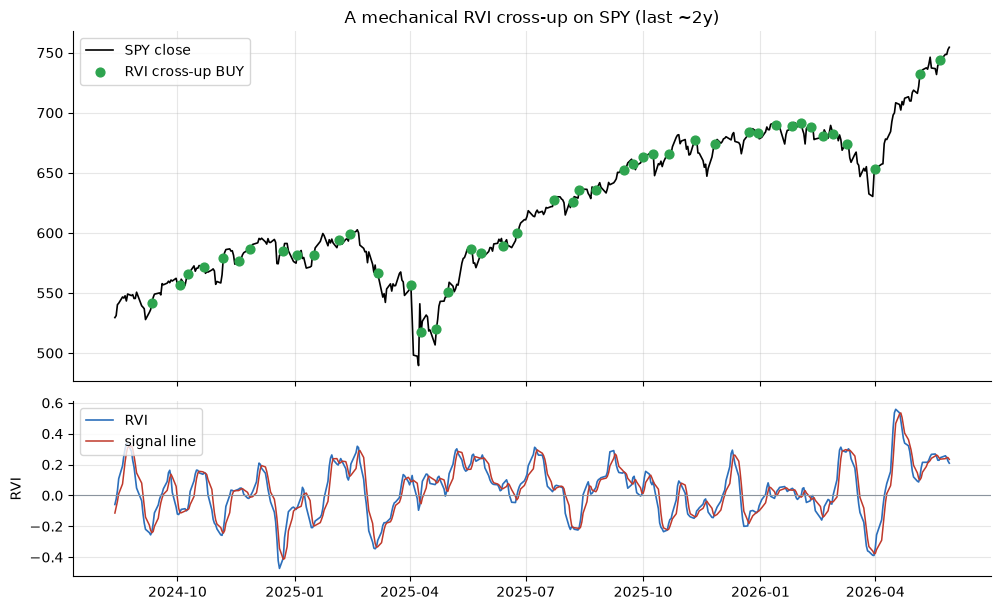

RVI cross-ups in window: 44


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    seg = b.iloc[-450:]
    ind = st.rvi(b, period=R['period'])
    ent = st.cross_up_entries(b, period=R['period'])
    ent = ent[ent >= seg.index[0]]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.2, 6.2), sharex=True,
                                   gridspec_kw={'height_ratios':[2,1]})
    ax1.plot(seg.index, seg['close'].values, c='k', lw=1.2, label='SPY close')
    ax1.scatter(ent, b['close'].reindex(ent), c=GREEN, s=40, zorder=5, label='RVI cross-up BUY')
    ax1.set_title('A mechanical RVI cross-up on SPY (last ~2y)'); ax1.legend(loc='upper left')
    ax2.plot(seg.index, ind['rvi'].reindex(seg.index), c='#2c6fbb', lw=1.2, label='RVI')
    ax2.plot(seg.index, ind['signal'].reindex(seg.index), c=RED, lw=1.1, label='signal line')
    ax2.axhline(0, c=GREY, lw=.8); ax2.legend(loc='upper left'); ax2.set_ylabel('RVI')
    plt.tight_layout(); plt.show()
    print('RVI cross-ups in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The RVI tracks momentum nicely — *as a description*. The question is whether those green buy dots are followed by rallies. **Let's race the cross-up against random entries** at four horizons. Blue = buy the cross; grey = buy on random days.

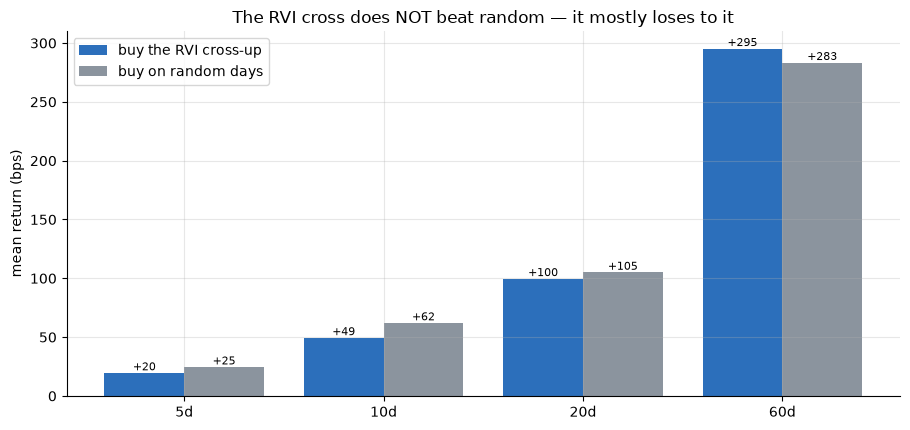

cross: [20, 49, 100, 295]
random: [25, 62, 105, 283]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    cross, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.cross_up_entries(bb, period=R['period'])
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        cross.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    cross = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, cross, .4, color='#2c6fbb', label='buy the RVI cross-up')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(cross,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The RVI cross does NOT beat random — it mostly loses to it'); ax.legend()
plt.tight_layout(); plt.show()
print('cross:', [round(v) for v in cross]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The cross-up makes money in absolute terms (**+100 bps** over 20 days) — but **random entries make as much or more** (**+105 bps**). At 5, 10 and 20 days the famous cross is *worse* than throwing darts. Only at 60 days does it nose ahead, and even then not by a statistically meaningful margin (the quants notebook shows the *t* never clears 2). The apparent edge was **the market's upward drift**, not the cross.

**One more sanity check.** What if we scramble the cross's *timing* — keep every RVI value but slide the indicator out of phase with price, so the crosses fall on meaningless dates? If the cross really forecasts, the scramble should do much worse.

In [4]:
if HAVE_REAL:
    pl = st.phase_scramble_placebo(load('SPY'), 20, period=R['period'], n_draws=300, seed=469)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real RVI cross-up (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *timing-scrambled* crosses do at least as well (p={pval:.2f}).')
print('=> the cross timing is not doing the work.')

real RVI cross-up (SPY, 20d): +93.3 bps
... but 58% of *timing-scrambled* crosses do at least as well (p=0.58).
=> the cross timing is not doing the work.


More than half of the **scrambled** crosses match or beat the real one (*p* = 0.56). If price genuinely followed *this specific cross*, a random re-alignment would collapse the result. It doesn't — because the result was never about the cross.

## 5 · The verdict

- **Signal — None.** The RVI cross-up does **not** beat buying on random days (it's *worse* at 5–20 days; the cross-vs-random difference never clears *t* = 2). The big absolute returns are the market's drift, not the cross.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"Does the RVI cross forecast"? — Busted.** Scramble the cross's timing and the result barely moves. The cross doesn't forecast.

## 6 · Could you actually trade it?

There's nothing here to trade. The cross's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The RVI buy is a worse, more expensive way to be long. Costs (commissions + spread on every cross) push the already-no-edge result further negative. As a forecasting tool it doesn't pay; as a momentum *description* it was never meant to be a strategy.

## 7 · Going further 🚪

- **Other crossover oscillators.** The Stochastic (%K/%D), MACD and Chande's momentum oscillators all sell the same signal-line-crossover trigger — and all land in the same place against the random baseline.
- **Different RVI periods.** Try a faster/slower N, or the zero-line cross instead of the signal-line cross — the result is robust: drift in, oscillator out.
- **A real positive control.** The quants notebook plants a *genuine* momentum regime into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the RVI cross forecasts? Show it beating random entries at **t ≥ 2** on a real tape — then we'll talk.*